In [1]:
import pandas as pd 
import pennylane.numpy as np 
import pennylane as qml
from silence_tensorflow import silence_tensorflow 
silence_tensorflow() 
import tensorflow as tf
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras import optimizers
from tensorflow.keras import activations
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
dataframe = pd.read_csv(r'temp.csv')
dataset = dataframe.values

X=dataset[:,3:]
Y=dataset[:,2:3]

scaler = MinMaxScaler()
StdScaler=scaler.fit(X)
# #Stdmean=scaler.mean_
X=scaler.transform(X)

scaler = MinMaxScaler()
StdScaler2=scaler.fit(Y)
# #Stdmean2=scaler.mean_
Y=scaler.transform(Y)

months = len(Y)
TRAIN_TEST_SPLIT = 0.962

split = split = int(months * TRAIN_TEST_SPLIT)
TrainX = X[0:split]
TestX = X[split:]

TrainY = Y[0:split]
TestY = Y[split:]


print("Len(Train):",len(TrainX))
print("Len(Test):",len(TestX))

Len(Train): 352
Len(Test): 14


In [3]:
def H_layer(n_qubits):
    for idx in range(n_qubits):
        qml.Hadamard(wires=idx)

def Data_AngleEmbedding_layer(inputs):
    qml.templates.AngleEmbedding(inputs,rotation='Y', wires=range(n_qubits))

def RY_layer(w):
    print(w.shape)
    for idx, element in enumerate(w):
        qml.RY(element, wires=idx)

def ROT_layer(w):
    for i in range(n_qubits):
        qml.Rot(*w[i],wires=i)

# def strong_entangling_layer(nqubits):
#     qml.CNOT(wires=[0,1])
#     qml.CNOT(wires=[1,2])
#     qml.CNOT(wires=[2,3])
#     qml.CNOT(wires=[3,0])
    
def entangling_layer(nqubits):
    for i in range(0, nqubits - 1, 2): 
        qml.CNOT(wires=[i, i + 1])
    for i in range(1, nqubits - 1, 2):  
        qml.CNOT(wires=[i, i + 1])

In [4]:
n_qubits = 6
n_layers = 1

dev = qml.device('default.qubit', wires=n_qubits)
@qml.qnode(dev)
def qnode(inputs, weights_1):
    H_layer(n_qubits)
    Data_AngleEmbedding_layer(inputs)
    for k in range(n_layers):
        entangling_layer(n_qubits)
        ROT_layer(weights_1[k])
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

In [5]:
weight_shapes = {"weights_1": (n_layers,n_qubits,3)}
qlayer = qml.qnn.KerasLayer(qnode, weight_shapes, output_dim=n_qubits)
Activation=tf.keras.layers.Activation(activations.linear)
clayer_2 = tf.keras.layers.Dense(1,kernel_initializer='normal')
model = tf.keras.models.Sequential([qlayer,Activation, clayer_2])
opt = tf.keras.optimizers.Adam(learning_rate=0.1)
model.compile(opt, loss="mae")

In [6]:
es=EarlyStopping(monitor='val_loss', min_delta=0, patience=6, verbose=1, mode='auto', baseline=None, restore_best_weights=True)
re=ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1, mode='min', min_lr=0.00001)
fitting = model.fit(TrainX, TrainY, epochs=30, batch_size=10, validation_split=0.1, callbacks=[re], verbose=1)

Epoch 1/30
32/32 [==============================] - 8s 197ms/step - loss: 0.1050 - val_loss: 0.0358 - lr: 0.1000
Epoch 2/30
32/32 [==============================] - 6s 176ms/step - loss: 0.0357 - val_loss: 0.0481 - lr: 0.1000
Epoch 3/30
32/32 [==============================] - 5s 172ms/step - loss: 0.0355 - val_loss: 0.0651 - lr: 0.1000
Epoch 4/30
32/32 [==============================] - 5s 172ms/step - loss: 0.0361 - val_loss: 0.0256 - lr: 0.1000
Epoch 5/30
32/32 [==============================] - 5s 167ms/step - loss: 0.0340 - val_loss: 0.0389 - lr: 0.1000
Epoch 6/30
32/32 [==============================] - 5s 168ms/step - loss: 0.0427 - val_loss: 0.0279 - lr: 0.1000
Epoch 7/30
32/32 [==============================] - ETA: 0s - loss: 0.0455
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.010000000149011612.
32/32 [==============================] - 5s 167ms/step - loss: 0.0455 - val_loss: 0.0537 - lr: 0.1000
Epoch 8/30
32/32 [==============================] - 5s 169ms/step - lo

In [7]:
y_predict=model.predict(TestX,verbose=1)
y_predict=y_predict.T
y_predict=y_predict[0]

1/1 [==============================] - 0s 130ms/step


In [8]:
newTestY = scaler.inverse_transform(TestY)
newy_predict = scaler.inverse_transform(y_predict.reshape(-1, 1))

In [9]:
from sklearn import metrics
print('Mean Absolute Error:', metrics.mean_absolute_error(newTestY, newy_predict))

Mean Absolute Error: 0.3832046018327979


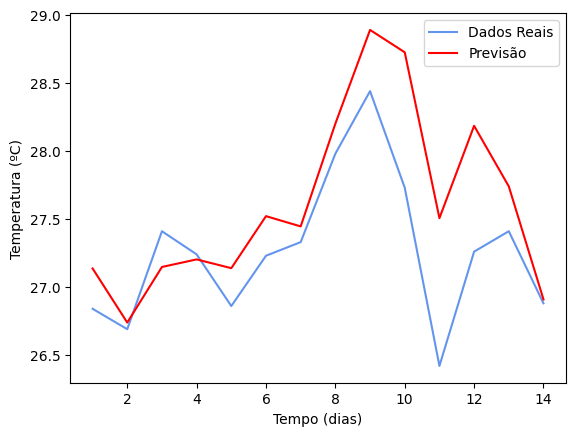

In [10]:
import matplotlib.pyplot as plt

# Ajustar o eixo x para começar a partir de 1
x_range = range(1, len(newTestY) + 1)

plt.plot(x_range, newTestY, color='cornflowerblue', linestyle='-', label='Dados Reais')
plt.plot(x_range, newy_predict, color='red', linestyle='-', label='Previsão')
plt.xlabel('Tempo (dias)')
plt.ylabel('Temperatura (ºC)')
plt.legend()
plt.show()

In [11]:
newTestY

array([[26.84],
       [26.69],
       [27.41],
       [27.24],
       [26.86],
       [27.23],
       [27.33],
       [27.98],
       [28.44],
       [27.73],
       [26.42],
       [27.26],
       [27.41],
       [26.88]])

In [12]:
newy_predict

array([[27.136562],
       [26.738674],
       [27.147268],
       [27.202969],
       [27.138508],
       [27.520945],
       [27.445423],
       [28.200886],
       [28.88969 ],
       [28.725168],
       [27.506142],
       [28.184803],
       [27.739552],
       [26.908749]], dtype=float32)

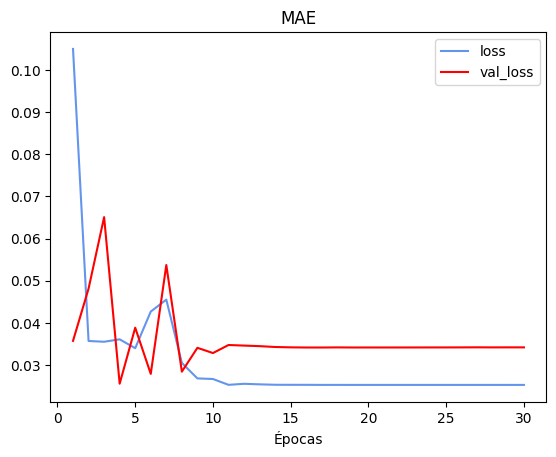

In [13]:
import matplotlib.pyplot as plt

# Ajustar o eixo x para começar em 1
epochs_adjusted = [epoch + 1 for epoch in fitting.epoch]

plt.plot(epochs_adjusted, fitting.history.get('loss'), color='cornflowerblue', linestyle='-', label='loss')
plt.plot(epochs_adjusted, fitting.history.get('val_loss'), color='red', linestyle='-', label='val_loss')
plt.title('MAE')
plt.xlabel('Épocas')  # Adicionando rótulo ao eixo x
plt.legend()
plt.show()

In [14]:
print(fitting.history.get('loss'))

[0.10495273768901825, 0.03573121130466461, 0.03554672375321388, 0.036123134195804596, 0.034018971025943756, 0.04270251467823982, 0.04553021863102913, 0.030520882457494736, 0.026862306520342827, 0.026720931753516197, 0.02533695101737976, 0.02558346651494503, 0.025454986840486526, 0.02535351552069187, 0.02534317597746849, 0.025338266044855118, 0.025320451706647873, 0.025322524830698967, 0.025319742038846016, 0.025319930166006088, 0.02532084658741951, 0.025319015607237816, 0.02531912922859192, 0.025318730622529984, 0.02531854435801506, 0.025318462401628494, 0.02531852014362812, 0.02531842328608036, 0.025317249819636345, 0.025317974388599396]


In [15]:
fitting.history.get('val_loss')

[0.03575465455651283,
 0.048145636916160583,
 0.06508271396160126,
 0.02560523711144924,
 0.038880378007888794,
 0.027930591255426407,
 0.05373283848166466,
 0.02846561186015606,
 0.0341116227209568,
 0.03287162631750107,
 0.034775510430336,
 0.03464062511920929,
 0.03450771048665047,
 0.034305740147829056,
 0.03422267735004425,
 0.03418508172035217,
 0.034183282405138016,
 0.0342104509472847,
 0.034189123660326004,
 0.03419134020805359,
 0.034190159291028976,
 0.034193191677331924,
 0.034197185188531876,
 0.03420192375779152,
 0.03420461714267731,
 0.034212876111269,
 0.03422726318240166,
 0.0342123806476593,
 0.0342203788459301,
 0.034217145293951035]